# Why do 245.tiff, 300.tiff and 301.tiff each miss exactly one mitotic figure?

**Question.** `results/precision_at_k_14roi_prodseed_chromatin_halfpixfix_raw.csv` (the D8-corrected,
current-production 14-ROI run) has `full_list_recall < 1.0` on exactly three of the 14 ROIs:

| ROI | domain | full_list_recall | missing |
|---|---|---:|---:|
| 245.tiff | canine lymphosarcoma | 0.988764 | 1 / 89 |
| 300.tiff | canine cutaneous mast cell tumor | 0.994444 | 1 / 180 |
| 301.tiff | canine cutaneous mast cell tumor | 0.995392 | 1 / 217 |

Every other ROI is at 1.000. This notebook re-runs the exact D8-corrected search + NMS pipeline
for just these three ROIs -- same seed draw (`ss.tightened_template_box`, gated, half-pixel-fixed
centre), same channel/method/deep-floor/NMS-radius config as
`production_seed_precision_at_k/production_seed_precision_at_k_chromatin_half_pix_fix.ipynb` --
but keeps the **pre-NMS raw peaks** and the **fused response map** that notebook discards, so the
one missed mitotic figure per ROI can be traced to a specific mechanism: never extracted (below
the deep floor), or extracted but suppressed by NMS in favour of a nearby stronger peak.

Nothing here changes the pipeline or any committed artefact -- this is a read-only diagnostic.

In [1]:
import time
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '..')

from midog_utils import channels as ch
from midog_utils import dataset as ds
from midog_utils import evaluate as ev
from midog_utils import find_and_suppress as fs
from midog_utils import seed_selection as ss
from midog_utils import template_match as tm
from midog_utils.nms import nms_by_distance

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)

# Identical to production_seed_precision_at_k_chromatin_half_pix_fix.ipynb -- D1/D2/D3/D7,
# SELF_HIT_RADIUS=5.0 (repo default, FSConfig.self_hit_radius), the same seed index and gate.
IMAGES_DIR = '../images/extra_valid'
SEED_INDEX = 0
CHANNEL = 'hematoxylin_od'
METHOD = cv2.TM_CCOEFF
PEAK_MIN_DISTANCE = 7
SELF_HIT_RADIUS = 5.0
DEEP_FLOOR_Z = -1.5
MAX_PEAKS = 2_000_000
NMS_RADIUS_UM = ev.MIDOG_RADIUS_UM
MATCH_RADIUS_UM = ev.MIDOG_RADIUS_UM
OTSU_WINDOW = tm.BASE_SIZE

CFG = fs.FSConfig(channel=CHANNEL, base_size=tm.BASE_SIZE, scales=(1.0,),
                  n_angles=1, flips=(False,), peak_min_distance=PEAK_MIN_DISTANCE,
                  self_hit_radius=SELF_HIT_RADIUS)
BORDER = CFG.patch_size // 2

TARGET_FILES = ['245.tiff', '300.tiff', '301.tiff']
print('config OK, targets:', TARGET_FILES)

config OK, targets: ['245.tiff', '300.tiff', '301.tiff']


In [2]:
def draw_seed_with_retry(pool, rng, check_fn):
    working, retries = pool.copy(), 0
    while len(working) > 0:
        idx = int(rng.integers(len(working)))
        row = working.iloc[idx]
        result = check_fn(row)
        if result is not None:
            return row, result, retries
        working = working.drop(working.index[idx])
        retries += 1
    raise ValueError('seed pool exhausted -- no candidate passed check_fn')


def suppress(centers, scores, radius, ref_xy, self_hit_radius=SELF_HIT_RADIUS):
    """NMS at `radius`, then drop the template's own self-correlation. Same as the
    production notebook's `suppress`, referenced to `ref_xy` = the D8 template centre."""
    keep = nms_by_distance(centers, scores, radius)
    c, s = centers[keep], scores[keep]
    if len(c):
        ok = np.hypot(c[:, 0] - ref_xy[0], c[:, 1] - ref_xy[1]) > self_hit_radius
        c, s = c[ok], s[ok]
    return c, s


def run_roi_diag(fn, image_id, domain, anns):
    """Same pipeline as the production notebook's `run_roi`, through NMS -- minus the
    chromatin/shape features (not needed here) -- but keeping the pre-NMS raw peaks and
    the fused response map instead of discarding them."""
    t0 = time.time()
    path = f'{IMAGES_DIR}/{fn}'
    rgb = ds.load_roi(path)
    mpp = ds.roi_mpp(path)
    roi_shape = rgb.shape
    match_radius = ev.radius_px(mpp, MATCH_RADIUS_UM)
    nms_radius = ev.radius_px(mpp, NMS_RADIUS_UM)
    hem = ch.to_channel(rgb, CHANNEL)
    gray_inv = ch.to_gray_inverted(rgb)
    H, W = hem.shape[:2]

    gt = ds.image_annotations(anns, fn)
    seed_pool, flagged = ss.agreement_pool(gt[gt['category_id'] == ds.MITOTIC])
    seed_pool = ss.border_filter(seed_pool, BORDER, roi_shape)
    rng = np.random.default_rng([SEED_INDEX, image_id])

    def _check(row):
        r = ss.tightened_template_box(gray_inv, float(row['cx']), float(row['cy']),
                                      otsu_window=OTSU_WINDOW)
        if r is None:
            return None
        if tm.read_padded_patch(hem, r[1], r[2], CFG.patch_size) is None:
            return None
        return r

    seed, seed_tpl, n_retries = draw_seed_with_retry(seed_pool, rng, _check)
    base_size, tpl_cx, tpl_cy = seed_tpl
    tpl_xy = (float(tpl_cx), float(tpl_cy))
    seed_xy = (float(seed['cx']), float(seed['cy']))
    seed_ann_id = int(seed['ann_id'])
    gt_eval = gt[gt['ann_id'] != seed_ann_id].reset_index(drop=True)

    patch = tm.read_padded_patch(hem, *tpl_xy, CFG.patch_size)
    templates, _ = tm.build_augmentations(patch, base_size, CFG.scales, CFG.n_angles, CFG.flips)
    PAD = max((t.shape[0] - 1) // 2 for t in templates)
    hem_p = cv2.copyMakeBorder(hem, PAD, PAD, PAD, PAD, borderType=cv2.BORDER_REPLICATE)
    fused_p, _, valid_p = tm.fused_response(hem_p, templates, CFG.scale_normalize, method=METHOD)
    fused = fused_p[PAD:PAD + H, PAD:PAD + W]
    valid = valid_p[PAD:PAD + H, PAD:PAD + W]
    assert bool(valid.all()), f'{fn}: padding left part of the ROI unreachable'

    med, mad = tm.robust_stats(fused, valid)
    cut = med + DEEP_FLOOR_Z * mad
    centers_raw, scores_raw = tm.extract_peaks(fused, valid, PEAK_MIN_DISTANCE, cut, MAX_PEAKS)
    c, s = suppress(centers_raw, scores_raw, nms_radius, tpl_xy)
    assert bool(np.all(np.diff(s) <= 0)), f'{fn}: post-NMS pool is not score-descending'
    pool = pd.DataFrame({'cx': c[:, 0], 'cy': c[:, 1], 'score': s})

    print(f'[{fn}] n_raw_peaks={len(centers_raw):6d}  n_post_nms={len(pool):5d}  '
          f'n_gt_mitotic={int((gt_eval.category_id==ds.MITOTIC).sum()):3d}  [{time.time()-t0:.0f}s]')

    return dict(fn=fn, domain=domain, mpp=mpp, roi_shape=roi_shape, rgb=rgb, hem=hem,
                fused=fused, med=med, mad=mad, cut=cut,
                match_radius=match_radius, nms_radius=nms_radius,
                tpl_xy=tpl_xy, base_size=base_size, seed_ann_id=seed_ann_id, seed_xy=seed_xy,
                n_retries=n_retries, centers_raw=centers_raw, scores_raw=scores_raw,
                pool=pool, gt=gt, gt_eval=gt_eval)

In [3]:
images, annotations = ds.load_annotations('../databases/MIDOG++.json')
ds.check_invariants(annotations)
meta_ix = images.set_index('file_name')[['image_id', 'tumor_type']]

t0 = time.time()
RESULTS = {}
for fn in TARGET_FILES:
    image_id = int(meta_ix.loc[fn, 'image_id'])
    domain = meta_ix.loc[fn, 'tumor_type']
    RESULTS[fn] = run_roi_diag(fn, image_id, domain, annotations)
print(f'\n{len(TARGET_FILES)} ROIs in {time.time()-t0:.0f}s')

[245.tiff] n_raw_peaks= 58880  n_post_nms=17678  n_gt_mitotic= 89  [9s]


[300.tiff] n_raw_peaks= 33132  n_post_nms=17940  n_gt_mitotic=180  [6s]


[301.tiff] n_raw_peaks= 36174  n_post_nms=17710  n_gt_mitotic=217  [6s]

3 ROIs in 22s


## Cross-check against the committed run

Before diagnosing anything, confirm this re-run reproduces the same pool size and the same
`full_list_recall` the committed 14-ROI notebook reports for these three ROIs -- otherwise the
"missing detection" here could be an artefact of this notebook, not the pipeline.

In [4]:
REF = pd.read_csv('../results/precision_at_k_14roi_prodseed_chromatin_halfpixfix_raw.csv')
REF = REF[REF['arm'] == 'tm_score'][['file_name', 'n_detections', 'full_list_recall']].drop_duplicates()
REF = REF.set_index('file_name')

rows = []
for fn in TARGET_FILES:
    res = RESULTS[fn]
    rows.append(dict(file_name=fn, n_detections_here=len(res['pool']),
                     n_detections_committed=int(REF.loc[fn, 'n_detections']),
                     full_list_recall_committed=float(REF.loc[fn, 'full_list_recall'])))
CHECK = pd.DataFrame(rows).set_index('file_name')
CHECK['pool_size_matches'] = CHECK['n_detections_here'] == CHECK['n_detections_committed']
print(CHECK)
assert CHECK['pool_size_matches'].all(), 'pool size mismatch -- this re-run diverged from the committed pipeline'
print('\npool sizes match the committed run on all three ROIs -- safe to diagnose.')

           n_detections_here  n_detections_committed  full_list_recall_committed  pool_size_matches
file_name                                                                                          
245.tiff               17678                   17678                    0.988764               True
300.tiff               17940                   17940                    0.994444               True
301.tiff               17710                   17710                    0.995392               True

pool sizes match the committed run on all three ROIs -- safe to diagnose.


## Find the missed mitotic annotation, per ROI

`evaluate.bucket_detections` is the same greedy-match function `compare.evaluate_arms` uses
internally for `full_list_recall` -- calling it directly on the `tm_score`-sorted pool marks
every ground-truth annotation `found=True/False`, which is exactly the label the committed CSV's
`full_list_recall` summarises.

In [5]:
MISSED = {}
for fn in TARGET_FILES:
    res = RESULTS[fn]
    pool_sorted = res['pool'].sort_values('score', ascending=False).reset_index(drop=True)
    det_out, gt_out = ev.bucket_detections(pool_sorted, res['gt_eval'], res['match_radius'])
    missed = gt_out[(gt_out['category_id'] == ds.MITOTIC) & (~gt_out['found'])]
    assert len(missed) == 1, f'{fn}: expected exactly 1 missed mitotic figure, found {len(missed)}'
    m = missed.iloc[0]
    MISSED[fn] = dict(ann_id=int(m['ann_id']), gx=float(m['cx']), gy=float(m['cy']))
    print(f"{fn}: missed ann_id={MISSED[fn]['ann_id']} at ({MISSED[fn]['gx']:.1f}, {MISSED[fn]['gy']:.1f})")

245.tiff: missed ann_id=6316 at (4860.0, 2219.0)


300.tiff: missed ann_id=14604 at (5960.0, 3678.0)


301.tiff: missed ann_id=14811 at (4958.0, 884.0)


## Diagnose the mechanism

For the missed annotation: find the nearest **pre-NMS** raw peak (was anything ever extracted
there at all?), check whether that peak survived NMS, and if it did not, identify the peak that
suppressed it. If no raw peak exists within one match radius at all, sample the fused response
map directly at and around the point to see how far below the deep floor it sits.

In [6]:
def diagnose(res, missed):
    gx, gy = missed['gx'], missed['gy']
    craw, sraw = res['centers_raw'], res['scores_raw']
    draw = np.hypot(craw[:, 0] - gx, craw[:, 1] - gy)
    i_near = int(np.argmin(draw))
    raw_xy, raw_d, raw_score = craw[i_near], float(draw[i_near]), float(sraw[i_near])
    within_mr = raw_d <= res['match_radius']

    pool = res['pool']
    dsurv = np.hypot(pool['cx'] - raw_xy[0], pool['cy'] - raw_xy[1])
    survived = bool((dsurv < 0.5).any())

    dgt_pool = np.hypot(pool['cx'] - gx, pool['cy'] - gy)
    j_pool = int(dgt_pool.idxmin())

    diag = dict(ann_id=missed['ann_id'], gx=gx, gy=gy,
                raw_xy=raw_xy, raw_d=raw_d, raw_score=raw_score, within_match_radius=within_mr,
                survived_nms=survived,
                nearest_pool_d=float(dgt_pool[j_pool]), nearest_pool_idx=j_pool,
                dist_to_seed_tpl=float(np.hypot(res['tpl_xy'][0] - gx, res['tpl_xy'][1] - gy)))

    if within_mr and not survived:
        dsupp = np.hypot(pool['cx'] - raw_xy[0], pool['cy'] - raw_xy[1])
        k = int(dsupp.idxmin())
        supp_xy = (float(pool.loc[k, 'cx']), float(pool.loc[k, 'cy']))
        diag.update(suppressor_xy=supp_xy, suppressor_score=float(pool.loc[k, 'score']),
                    suppressor_dist_to_raw=float(dsupp[k]),
                    suppressor_dist_to_gt=float(np.hypot(supp_xy[0] - gx, supp_xy[1] - gy)))

    if not within_mr:
        half = int(res['match_radius'] * 3)
        iy, ix = int(round(gy)), int(round(gx))
        H, W = res['fused'].shape
        y0, y1 = max(0, iy - half), min(H, iy + half + 1)
        x0, x1 = max(0, ix - half), min(W, ix + half + 1)
        crop = res['fused'][y0:y1, x0:x1]
        resp_at_gt = float(res['fused'][iy, ix])
        resp_max = float(crop.max())
        diag.update(response_at_gt=resp_at_gt, response_max_nearby=resp_max,
                    z_at_gt=(resp_at_gt - res['med']) / res['mad'],
                    z_max_nearby=(resp_max - res['med']) / res['mad'])
    return diag


DIAGS = {}
for fn in TARGET_FILES:
    DIAGS[fn] = diagnose(RESULTS[fn], MISSED[fn])

In [7]:
for fn in TARGET_FILES:
    res, diag = RESULTS[fn], DIAGS[fn]
    print(f"=== {fn}  (domain={res['domain']}) ===")
    print(f"  missed ann_id={diag['ann_id']} at ({diag['gx']:.1f}, {diag['gy']:.1f})")
    print(f"  match_radius={res['match_radius']:.2f}px  nms_radius={res['nms_radius']:.2f}px  "
          f"self_hit_radius={SELF_HIT_RADIUS}px  deep_floor_z={DEEP_FLOOR_Z}")
    print(f"  nearest pre-NMS raw peak: {diag['raw_d']:.2f}px away, score={diag['raw_score']:.3f}, "
          f"within_match_radius={diag['within_match_radius']}, survived_NMS={diag['survived_nms']}")
    if 'suppressor_xy' in diag:
        stolen = diag['suppressor_dist_to_gt'] <= res['match_radius']
        print(f"  --> SUPPRESSED BY NMS. A candidate {diag['suppressor_dist_to_raw']:.2f}px from the "
              f"raw peak scored {diag['suppressor_score']:.3f} (vs {diag['raw_score']:.3f}) and won "
              f"the NMS competition. That survivor sits {diag['suppressor_dist_to_gt']:.2f}px from the "
              f"missed GT itself -- {'ALSO within match radius, so the greedy match assigned the slot to a competing annotation instead' if stolen else 'outside match radius: an unrelated, unconnected peak simply won the local competition'}.")
    if not diag['within_match_radius']:
        print(f"  --> NEVER EXTRACTED. No raw peak within one match radius. Fused response at the GT "
              f"pixel itself: z={diag['z_at_gt']:.2f}; best z anywhere within 3x match radius: "
              f"{diag['z_max_nearby']:.2f} (deep floor is z={DEEP_FLOOR_Z}, cut={res['cut']:.4f}).")
    print(f"  distance from missed GT to the removed seed's D8 template centre: "
          f"{diag['dist_to_seed_tpl']:.1f}px")
    print()

=== 245.tiff  (domain=canine lymphosarcoma) ===
  missed ann_id=6316 at (4860.0, 2219.0)
  match_radius=30.22px  nms_radius=30.22px  self_hit_radius=5.0px  deep_floor_z=-1.5
  nearest pre-NMS raw peak: 7.07px away, score=0.560, within_match_radius=True, survived_NMS=False
  --> SUPPRESSED BY NMS. A candidate 28.23px from the raw peak scored 0.637 (vs 0.560) and won the NMS competition. That survivor sits 31.58px from the missed GT itself -- outside match radius: an unrelated, unconnected peak simply won the local competition.
  distance from missed GT to the removed seed's D8 template centre: 2253.0px

=== 300.tiff  (domain=canine cutaneous mast cell tumor) ===
  missed ann_id=14604 at (5960.0, 3678.0)
  match_radius=29.61px  nms_radius=29.61px  self_hit_radius=5.0px  deep_floor_z=-1.5
  nearest pre-NMS raw peak: 4.47px away, score=1.478, within_match_radius=True, survived_NMS=False
  --> SUPPRESSED BY NMS. A candidate 25.71px from the raw peak scored 1.658 (vs 1.478) and won the NMS c

## Visual: RGB crop and fused-response heatmap around each missed annotation

Left panel: the RGB image around the missed mitotic figure, with the match-radius circle, nearby
ground-truth annotations, the removed seed click, the nearest pre-NMS raw peak, and the nearest
surviving post-NMS candidate all marked. Right panel: the same crop of the fused response map in
robust-z units, with the deep-floor cut drawn as a red contour, so it is visible whether the map
ever rises to the extraction floor near the missed figure.

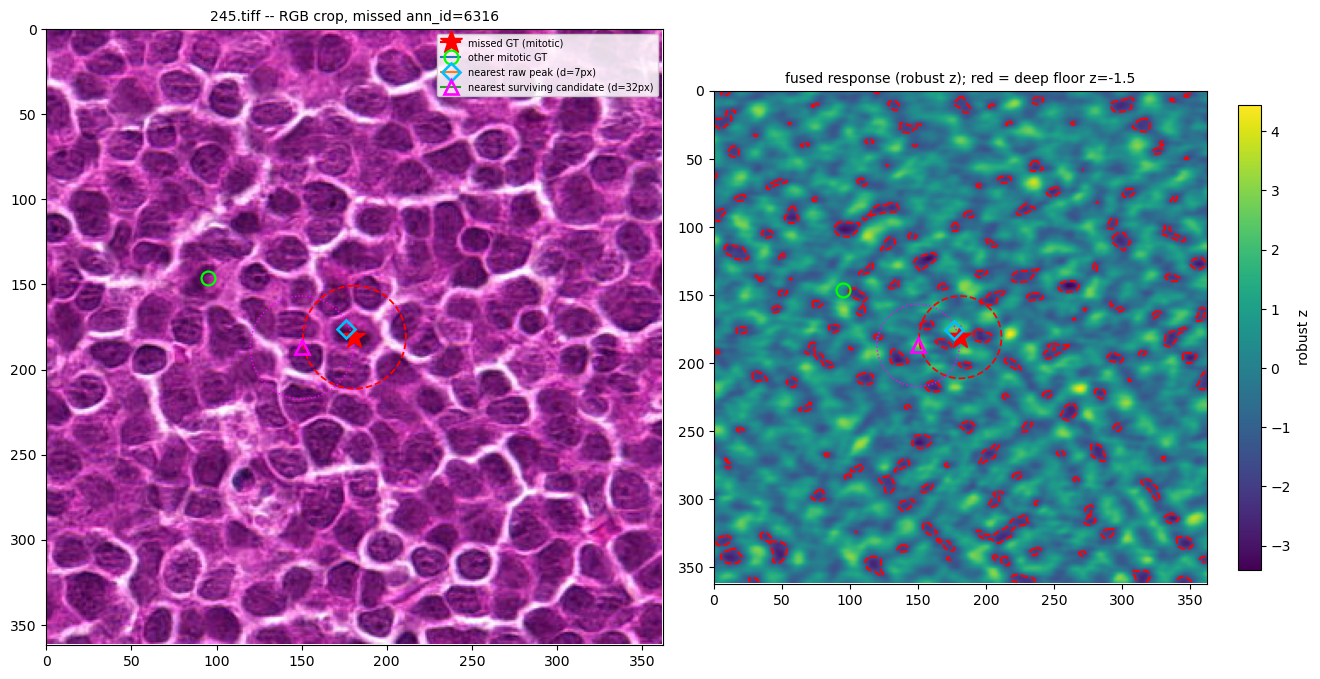

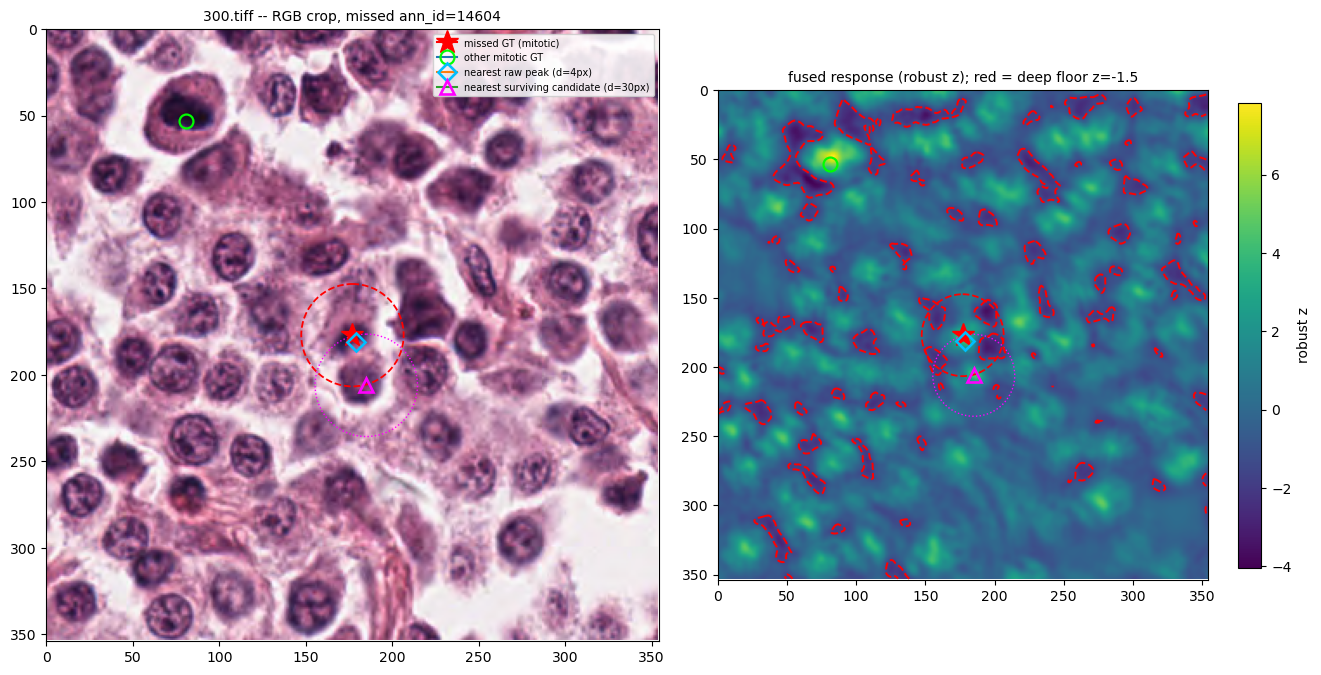

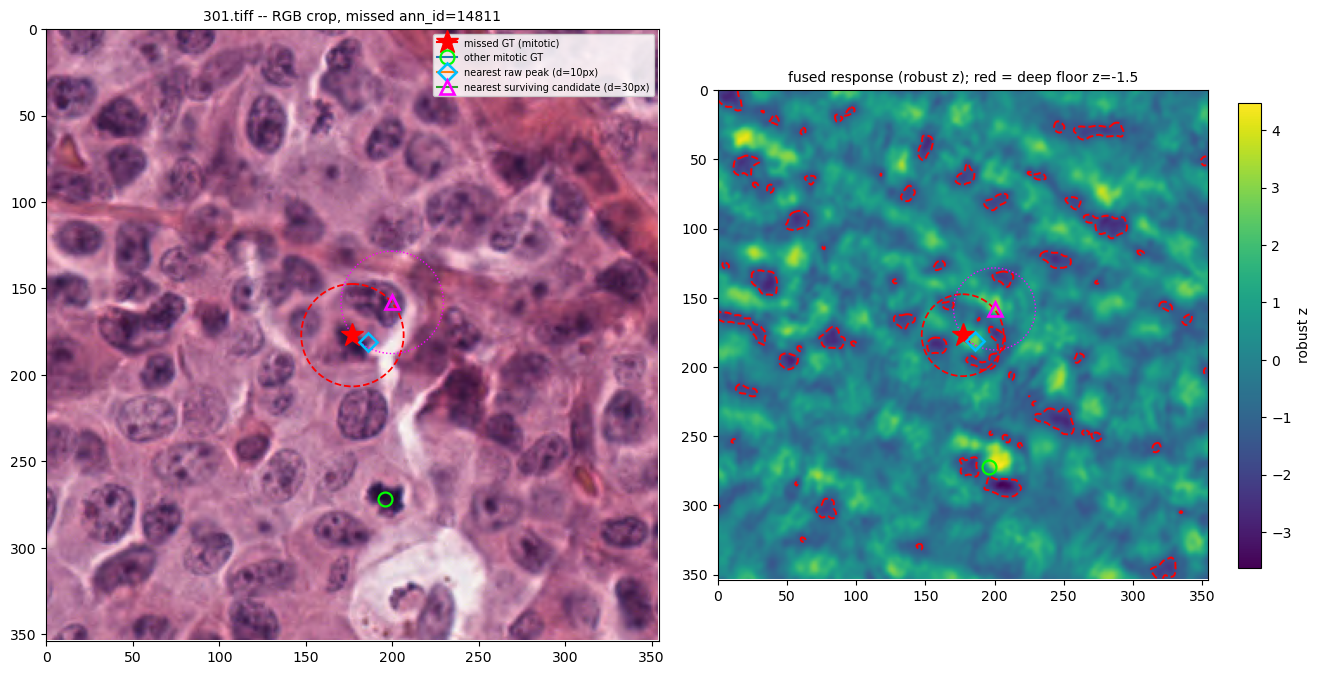

In [8]:
def plot_diag(res, diag):
    fn = res['fn']
    gx, gy = diag['gx'], diag['gy']
    H, W = res['fused'].shape
    half = max(150, int(res['match_radius'] * 6))
    x0, x1 = max(0, int(gx - half)), min(W, int(gx + half))
    y0, y1 = max(0, int(gy - half)), min(H, int(gy + half))
    rgb_crop = res['rgb'][y0:y1, x0:x1]
    z_crop = (res['fused'][y0:y1, x0:x1] - res['med']) / res['mad']

    fig, axes = plt.subplots(1, 2, figsize=(13.5, 6.6))
    axes[0].imshow(rgb_crop)
    axes[0].set_title(f'{fn} -- RGB crop, missed ann_id={diag["ann_id"]}', fontsize=10)
    im = axes[1].imshow(z_crop, cmap='viridis')
    cs = axes[1].contour(z_crop, levels=[DEEP_FLOOR_Z], colors='red', linewidths=1.4)
    axes[1].set_title(f'fused response (robust z); red = deep floor z={DEEP_FLOOR_Z}', fontsize=10)
    fig.colorbar(im, ax=axes[1], shrink=0.75, label='robust z')

    def mark(ax, x, y, **kw):
        ax.plot(x - x0, y - y0, **kw)

    handles_done = False
    for ax in axes:
        ax.set_xlim(0, x1 - x0)
        ax.set_ylim(y1 - y0, 0)
        circ = plt.Circle((gx - x0, gy - y0), res['match_radius'], fill=False,
                          color='red', lw=1.3, ls='--')
        ax.add_patch(circ)
        mark(ax, gx, gy, marker='*', color='red', markersize=17,
             label='missed GT (mitotic)' if not handles_done else None)

        for _, row in res['gt_eval'].iterrows():
            if int(row['ann_id']) == diag['ann_id']:
                continue
            if not (x0 <= row['cx'] <= x1 and y0 <= row['cy'] <= y1):
                continue
            color = 'lime' if row['category_id'] == ds.MITOTIC else 'orange'
            lbl = ('other mitotic GT' if row['category_id'] == ds.MITOTIC else 'look-alike GT') if not handles_done else None
            mark(ax, row['cx'], row['cy'], marker='o', mfc='none', mec=color, markersize=10, mew=1.6, label=lbl)

        sx, sy = res['seed_xy']
        if x0 <= sx <= x1 and y0 <= sy <= y1:
            mark(ax, sx, sy, marker='x', color='dimgray', markersize=11, mew=2.2,
                 label='removed seed click' if not handles_done else None)

        rx, ry = diag['raw_xy']
        if x0 <= rx <= x1 and y0 <= ry <= y1:
            mark(ax, rx, ry, marker='D', mfc='none', mec='deepskyblue', markersize=9, mew=1.9,
                 label=f"nearest raw peak (d={diag['raw_d']:.0f}px)" if not handles_done else None)

        pr = res['pool'].loc[diag['nearest_pool_idx']]
        if x0 <= pr['cx'] <= x1 and y0 <= pr['cy'] <= y1:
            mark(ax, pr['cx'], pr['cy'], marker='^', mfc='none', mec='magenta', markersize=10, mew=1.9,
                 label=f"nearest surviving candidate (d={diag['nearest_pool_d']:.0f}px)" if not handles_done else None)

        if 'suppressor_xy' in diag:
            sxp, syp = diag['suppressor_xy']
            if x0 <= sxp <= x1 and y0 <= syp <= y1:
                circ2 = plt.Circle((sxp - x0, syp - y0), res['nms_radius'], fill=False,
                                   color='magenta', lw=1.0, ls=':')
                ax.add_patch(circ2)
        handles_done = True

    axes[0].legend(fontsize=7, loc='upper right', framealpha=0.85)
    plt.tight_layout()
    plt.savefig(f'missed_mitosis_{fn.replace(".tiff", "")}.png', dpi=140, bbox_inches='tight')
    plt.show()


for fn in TARGET_FILES:
    plot_diag(RESULTS[fn], DIAGS[fn])

## What is the peak that won the NMS competition?

Each suppressor sits outside match radius of the missed GT, so it did not itself claim that
annotation. Check what it actually is: distance to the nearest annotation of *any* category in
the ROI (mitotic or look-alike), to see whether it is a second real structure or unannotated
clutter that simply scored higher on raw `TM_CCOEFF`.

In [9]:
for fn in TARGET_FILES:
    res, diag = RESULTS[fn], DIAGS[fn]
    if 'suppressor_xy' not in diag:
        continue
    sx, sy = diag['suppressor_xy']
    gt_all = res['gt']
    d_any = np.hypot(gt_all['cx'] - sx, gt_all['cy'] - sy)
    j = int(d_any.idxmin())
    nearest = gt_all.loc[j]
    cat = 'mitotic' if nearest['category_id'] == ds.MITOTIC else 'look-alike'
    print(f"{fn}: suppressor peak at ({sx:.0f},{sy:.0f}), score={diag['suppressor_score']:.3f} -- "
          f"nearest annotation of ANY kind is ann_id={int(nearest['ann_id'])} ({cat}), "
          f"{d_any[j]:.1f}px away "
          f"({'within' if d_any[j] <= res['match_radius'] else 'OUTSIDE'} match radius "
          f"{res['match_radius']:.1f}px) "
          f"{'-- same annotation as the missed one' if int(nearest['ann_id'])==diag['ann_id'] else ''}")


245.tiff: suppressor peak at (4829,2225), score=0.637 -- nearest annotation of ANY kind is ann_id=6316 (mitotic), 31.6px away (OUTSIDE match radius 30.2px) -- same annotation as the missed one
300.tiff: suppressor peak at (5968,3707), score=1.658 -- nearest annotation of ANY kind is ann_id=14604 (mitotic), 30.1px away (OUTSIDE match radius 29.6px) -- same annotation as the missed one
301.tiff: suppressor peak at (4981,865), score=0.647 -- nearest annotation of ANY kind is ann_id=14811 (mitotic), 29.8px away (OUTSIDE match radius 29.6px) -- same annotation as the missed one


## Verdict

One line per ROI, filled in from the printed diagnosis and figures above once run.